In [20]:
import torch
import torch.nn.utils.prune as prune
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.nn.utils.prune as prune
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from models import ResNet18
from torchinfo import summary

In [21]:
# Load ResNet model
model = ResNet18()
checkpoint = torch.load('Models Weights/Resnet18_V2.pth', map_location='cuda')
state_dict = checkpoint['net']

/tmp/ipykernel_3750723/1163781334.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('Models Weights/Resnet18_V2.pth', map_location='cuda')


In [22]:
# Remove 'module.' if using DataParallel
new_state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
model.load_state_dict(new_state_dict)

<All keys matched successfully>

In [23]:
# Move model to GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

In [24]:
# Lists to track metrics
train_losses = []
train_accs = []
test_losses = []
test_accs = []
best_epoch = 0
best_state = None

In [25]:
# Data
print('==> Preparing data..')
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=100, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

==> Preparing data..
Files already downloaded and verified
Files already downloaded and verified


In [26]:
def evaluate(model, test_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            inputs = inputs.half()  # Convert input to half precision
            outputs = model(inputs)  # Model is already in half precision
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    acc = 100 * correct / total
    print(f"Half Precision Model Accuracy: {acc:.2f}%")
    return acc

In [27]:
# Use model.half to quantize the model
model.half()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=

In [28]:
# Evaluate the quantized model
evaluate(model, testloader)

Half Precision Model Accuracy: 95.44%


95.44

In [29]:
summary(model, input_size=(128, 3, 32, 32), dtypes=[torch.float16], device=device)

/opt/img/effdl-venv/lib/python3.12/site-packages/torchinfo/torchinfo.py:216: UserWarning: Half precision is not supported with input_size parameter, and may output incorrect results. Try passing input_data directly.
  validate_user_params(


Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [128, 10]                 --
├─Conv2d: 1-1                            [128, 64, 32, 32]         1,728
├─BatchNorm2d: 1-2                       [128, 64, 32, 32]         128
├─Sequential: 1-3                        [128, 64, 32, 32]         --
│    └─BasicBlock: 2-1                   [128, 64, 32, 32]         --
│    │    └─Conv2d: 3-1                  [128, 64, 32, 32]         36,864
│    │    └─BatchNorm2d: 3-2             [128, 64, 32, 32]         128
│    │    └─Conv2d: 3-3                  [128, 64, 32, 32]         36,864
│    │    └─BatchNorm2d: 3-4             [128, 64, 32, 32]         128
│    │    └─Sequential: 3-5              [128, 64, 32, 32]         --
│    └─BasicBlock: 2-2                   [128, 64, 32, 32]         --
│    │    └─Conv2d: 3-6                  [128, 64, 32, 32]         36,864
│    │    └─BatchNorm2d: 3-7             [128, 64, 32, 32]         

In [30]:
# list of pruning amounts
pruning_amounts = [0, 0.2, 0.4, 0.6, 0.7, 0.75, 0.77, 0.78, 0.79, 0.8, 0.85, 0.9, 0.95, 0.99]
# Define pruning parameters
pruning_method = prune.L1Unstructured  # Use L1 unstructured pruning
# Define parameters to prune (e.g., all convolutional layers)
parameters_to_prune = []
for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        parameters_to_prune.append((module, 'weight'))

Half Precision Model Accuracy: 95.44%
Half Precision Model Accuracy: 95.45%
Half Precision Model Accuracy: 95.42%
Half Precision Model Accuracy: 95.24%
Half Precision Model Accuracy: 94.90%
Half Precision Model Accuracy: 93.63%
Half Precision Model Accuracy: 92.11%
Half Precision Model Accuracy: 91.21%
Half Precision Model Accuracy: 89.70%
Half Precision Model Accuracy: 87.95%
Half Precision Model Accuracy: 57.04%
Half Precision Model Accuracy: 30.03%
Half Precision Model Accuracy: 30.46%
Half Precision Model Accuracy: 10.90%


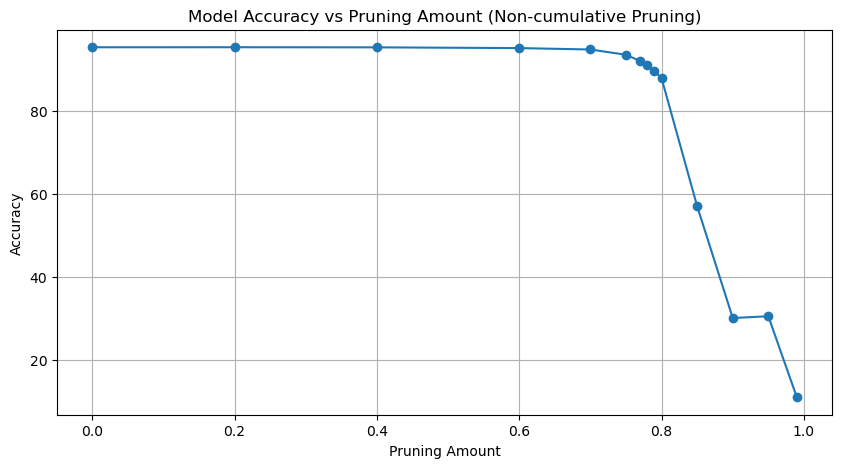

In [31]:
# Pruning from the same original model for each amount (non-cumulative)
import copy

accuracies = []

# Build a clean base model once from original checkpoint weights
base_model = ResNet18().to(device)
base_model.load_state_dict(new_state_dict)
base_model.half()

for amount in pruning_amounts:
    # Fresh copy every iteration so pruning does NOT accumulate
    model_pruned = copy.deepcopy(base_model)

    # Collect layers to prune on this fresh model
    parameters_to_prune = [
        (module, 'weight')
        for module in model_pruned.modules()
        if isinstance(module, nn.Conv2d)
    ]

    prune.global_unstructured(
        parameters_to_prune,
        pruning_method=pruning_method,
        amount=amount,
    )

    acc = evaluate(model_pruned, testloader)
    accuracies.append(acc)

# Plotting
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(pruning_amounts, accuracies, marker='o')
plt.xlabel('Pruning Amount')
plt.ylabel('Accuracy')
plt.title('Model Accuracy vs Pruning Amount (Non-cumulative Pruning)')
plt.grid(True)
plt.show()

In [ ]:
def compute_effdl_score(p_s, p_u, q_w, q_a, w, f,
                        ref_params=5.6e6,
                        ref_ops=2.8e8):
    """
    Compute the lab score:

    score = [1 - (p_s + p_u)] * ((q_w / 32) * w) / ref_params
          + (1 - p_s) * (max(q_w, q_a) / 32) * f / ref_ops

    Args:
        p_s (float): structured pruning ratio in [0, 1]
        p_u (float): unstructured pruning ratio in [0, 1]
        q_w (float): weight bit-width (e.g., 32, 16, 8, 1)
        q_a (float): activation bit-width (e.g., 32, 16, 8)
        w (float): number of weights (parameters)
        f (float): number of MACs
    """
    if not (0.0 <= p_s <= 1.0 and 0.0 <= p_u <= 1.0):
        raise ValueError("p_s and p_u must be in [0, 1].")
    if p_s + p_u > 1.0:
        raise ValueError("p_s + p_u must be <= 1.")
    if min(q_w, q_a, w, f) < 0:
        raise ValueError("q_w, q_a, w, and f must be non-negative.")

    params_term = (1.0 - (p_s + p_u)) * ((q_w / 32.0) * w) / ref_params
    ops_term = (1.0 - p_s) * (max(q_w, q_a) / 32.0) * f / ref_ops
    return params_term + ops_term


# Example (ResNet18 FP16 baseline should be close to 2.0):
baseline_score = compute_effdl_score(p_s=0.0, p_u=0.77, q_w=8, q_a=8, w=5.6e6, f=2.8e8)
print(f"Baseline score: {baseline_score:.4f}")

Baseline score: 0.1537


Half Precision Model Accuracy: 92.11%
==> TensorBoard logging to: runs/cifar10_resnet18_augmix_20260224_145851
==> Start TensorBoard with: tensorboard --logdir=runs
==> Preparing data..
Files already downloaded and verified
Files already downloaded and verified
==> Building model..

Epoch: 0
 [================================================================>]  Step: 108ms | Tot: 1m10s | Loss: 1.108 | Acc: 71.124% (35561/5000 391/391 1  
 [================================================================>]  Step: 57ms | Tot: 5s667ms | Loss: 0.335 | Acc: 93.320% (9332/1000 100/100 
Saving..

Epoch: 1
 [================================================================>]  Step: 108ms | Tot: 1m10s | Loss: 1.040 | Acc: 72.468% (36234/5000 391/391 1  
 [================================================================>]  Step: 57ms | Tot: 5s666ms | Loss: 0.316 | Acc: 94.020% (9402/1000 100/100 
Saving..

Epoch: 2
 [================================================================>]  Step: 108ms |

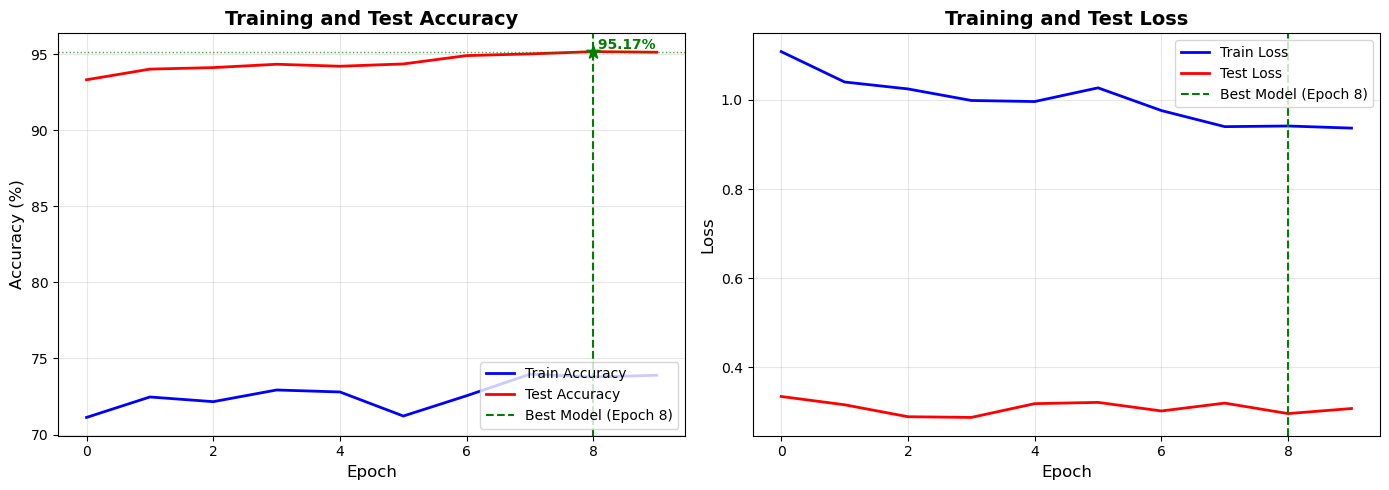

Best model achieved 95.17% accuracy at epoch 8
Best model saved at ./Models Weights/Resnet18_base_pruned80_augmix_10ep.pth

==> TensorBoard logs saved. View with: tensorboard --logdir=runs
Best acc: 95.17%
Best epoch: 8
Saved: ./Models Weights/Resnet18_base_pruned80_augmix_10ep.pth


In [39]:
import copy

import importlib

import train_augmentation



# Recharge le module pour prendre les dernières modifs du fichier

importlib.reload(train_augmentation)



# Partir du modèle de base, puis le pruner avant entraînement

prune_amount = 0.77

model_to_train = copy.deepcopy(base_model)



parameters_to_prune = [

    (module, 'weight')

    for module in model_to_train.modules()

    if isinstance(module, nn.Conv2d)

]



prune.global_unstructured(

    parameters_to_prune,

    pruning_method=prune.L1Unstructured,

    amount=prune_amount,

)

evaluate(model_to_train,testloader)


# Entraîner le modèle pruné pendant 10 epochs (sans resume)

results_augmix_prune_10ep = train_augmentation.train_with_augmentation(

    model=model_to_train,

    epochs=10,

    resume=False,

    mixup=True,

    mixup_alpha=1.0,

    save_name='Resnet18_base_pruned80_augmix_10ep',
    
    lr=0.01

)



print(f"Best acc: {results_augmix_prune_10ep['best_acc']:.2f}%")

print(f"Best epoch: {results_augmix_prune_10ep['best_epoch']}")

print(f"Saved: {results_augmix_prune_10ep['save_path']}")
